# Assignment 4 — SIRD Model: Bayesian Inference of the Death Rate μ

The original program estimates the basic reproduction number $R_0$ of the **SIR** model from noisy epidemic data using MCMC. With $\gamma = 1$ (scaled time), only the infected $I(t)$ and recovered $R(t)$ curves are needed.

**Our task:** Extend the model to **SIRD** by introducing a death compartment $D(t)$ and a death rate $\mu$.
- Fix $\gamma = 1$ and $\beta = 2.5$
- Infer $\mu$ from noisy $S(t)$, $I(t)$, $R(t)$, $D(t)$ curves
- Initial conditions: $i_0 = 0.01,\ s_0 = 0.99,\ r_0 = 0,\ d_0 = 0$; time parameters: $f = 3.0$, timestep $= 0.5$
- Log-normal observation noise $\sigma \in [0.2, 0.4]$
- Assess inference quality with **HPD (Highest Posterior Density)** plots
- **Optional:** Does inference still work if $S(t)$ and/or $R(t)$ are not observed?

## 1. Mathematical Background

### 1.1 The SIRD Model

The SIRD model extends SIR by splitting the removed compartment into **Recovered** and **Dead**:

$$\frac{dS}{dt} = -\beta\, S\, I$$
$$\frac{dI}{dt} = \beta\, S\, I - \gamma\, I - \mu\, I$$
$$\frac{dR}{dt} = \gamma\, I$$
$$\frac{dD}{dt} = \mu\, I$$

where $S + I + R + D = 1$ (population fractions), $\beta$ is the infection rate, $\gamma$ the recovery rate, and $\mu$ the death rate — our inference target.

### 1.2 Scaled Time & Conservation Law

With $\gamma = 1$, time is measured in units of $1/\gamma$. The basic reproduction number becomes:

$$R_0 = \frac{\beta}{\gamma + \mu} = \frac{2.5}{1 + \mu}$$

Since $S = 1 - I - R - D$, we only need to integrate **3 states** $(I, R, D)$ and reconstruct $S$ analytically. This avoids redundant integration.

### 1.3 Bayesian Inference via MCMC

We treat $\mu$ as an unknown and infer its posterior distribution from noisy data:

$$P(\mu \mid \mathcal{D}) \propto P(\mathcal{D} \mid \mu)\; P(\mu)$$

- **Prior** $P(\mu)$: `TruncatedNormal` — encodes that $\mu \geq 0$, centred near a small positive value
- **Likelihood** $P(\mathcal{D} \mid \mu)$: Log-normal — appropriate for multiplicative noise on strictly positive fractions
- **Sampler**: NUTS (No-U-Turn Sampler), a gradient-based Hamiltonian Monte Carlo variant that efficiently explores continuous posteriors

## 2. Setup & Imports

In [1]:
# macOS / PyTensor compiler workaround — only needed on macOS, safe to skip on other platforms
import os, sys, subprocess

if sys.platform == "darwin":
    try:
        sdk = subprocess.check_output(["xcrun", "--show-sdk-path"], text=True).strip()
        os.environ.setdefault("SDKROOT", sdk)
        import pytensor
        pytensor.config.cxx = "/usr/bin/clang++"
        pytensor.config.gcc__cxxflags = f"-I{sdk}/usr/include/c++/v1"
        print("PyTensor configured for macOS SDK:", pytensor.config.gcc__cxxflags)
    except Exception as exc:
        print("macOS workaround failed (non-fatal):", repr(exc))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from pymc.ode import DifferentialEquation
from scipy.integrate import odeint
import warnings
warnings.filterwarnings("ignore")

%precision 4
%matplotlib inline

np.random.seed(42)

print(f"PyMC  version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

c:\Users\starry\mambaforge\envs\pymc_env\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PyMC  version: 5.28.5
ArviZ version: 0.23.4


## 3. SIRD ODE System & Parameters

We define the ground truth parameters and the SIRD ODE. The state vector is $y = [I, R, D]$; $S$ is recovered from the conservation law $S = 1 - I - R - D$, avoiding a redundant fourth equation.

The only free parameter is `p[0]` $= \mu$ — the quantity we want MCMC to infer. $\beta = 2.5$ and $\gamma = 1$ are fixed.

In [3]:
# ── Ground truth parameters ──────────────────────────────────────────────────
beta    = 2.5   # infection rate (fixed)
gamma   = 1.0   # recovery rate  (fixed, defines the time scale)
mu_true = 0.3   # TRUE death rate — this is what MCMC will try to recover

# ── Initial conditions (fractions of total population) ───────────────────────
i0 = 0.01   # infected at t=0
r0 = 0.00   # recovered at t=0
d0 = 0.00   # dead at t=0
s0 = 1 - i0 - r0 - d0  # susceptible at t=0 (= 0.99)

# ── Time grid ─────────────────────────────────────────────────────────────────
f             = 3.0   # sets the total time window: T = 5*f = 15
timestep_data = 0.5   # observation interval

print(f"Fixed:    β = {beta}, γ = {gamma}")
print(f"Target:   μ = {mu_true}")
print(f"True R₀ = β / (γ + μ) = {beta / (gamma + mu_true):.4f}")
print(f"Initial:  S={s0}, I={i0}, R={r0}, D={d0}")

Fixed:    β = 2.5, γ = 1.0
Target:   μ = 0.3
True R₀ = β / (γ + μ) = 1.9231
Initial:  S=0.99, I=0.01, R=0.0, D=0.0


In [4]:
def SIRD(y, t, p):
    """
    SIRD ODE system in scaled time (γ = 1, β = 2.5 fixed).

    States:     y[0] = I (infected)
                y[1] = R (recovered)
                y[2] = D (dead)
    Parameter:  p[0] = μ (death rate — inferred by MCMC)

    S is not integrated; it is reconstructed from conservation: S = 1 - I - R - D.
    """
    I, R, D = y[0], y[1], y[2]
    S = 1 - I - R - D   # conservation law: avoids integrating a 4th equation

    mu = p[0]

    dI = beta * S * I - I - mu * I   # new infections minus recoveries minus deaths
    dR = I                            # γ·I with γ=1
    dD = mu * I                       # deaths proportional to infected

    return [dI, dR, dD]

## 4. Generate Synthetic Observations

We integrate the SIRD system with the **true** $\mu$ to obtain deterministic epidemic curves, then add **multiplicative log-normal noise** to simulate realistic observations.

Log-normal noise is the right choice here because:
- The compartment values are always strictly positive fractions
- Real epidemic counts have relative (percentage) errors, not absolute ones

We skip $t = 0$ when generating observations because $R(0) = D(0) = 0$, and $\log(0)$ is undefined.

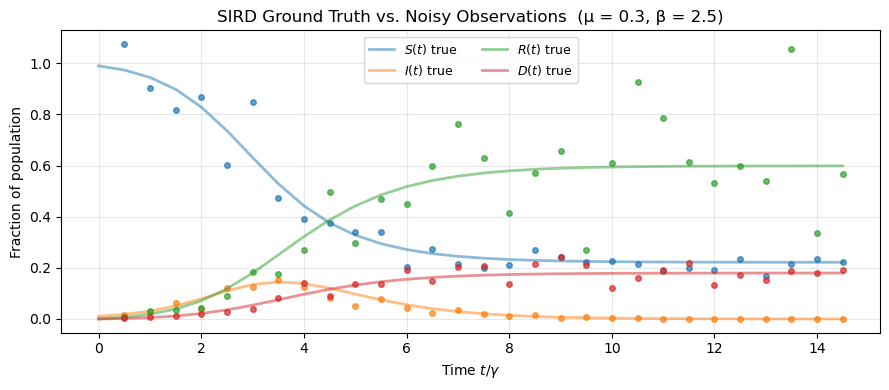

In [5]:
# Noise levels (log-normal σ) for each compartment: S, I, R, D
SIGMA_OBS = [0.20, 0.35, 0.30, 0.20]   # all within the required 0.2–0.4 range

# ── Integrate the ODE with the true parameters ────────────────────────────────
times = np.arange(0, 5 * f, timestep_data)
y = odeint(SIRD, y0=[i0, r0, d0], t=times, args=([mu_true],), rtol=1e-8)

# Reconstruct S from conservation law
S_true      = 1 - y[:, 0] - y[:, 1] - y[:, 2]
full_curves = np.column_stack([S_true, y])   # shape (T, 4): columns = S, I, R, D

# ── Add log-normal noise (skip t=0 to avoid log(0)) ──────────────────────────
yobs_full = np.random.lognormal(mean=np.log(full_curves[1:]), sigma=SIGMA_OBS)

# ── Plot: deterministic curves + noisy observations ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["C0", "C1", "C2", "C3"]
labels = ["S(t)", "I(t)", "R(t)", "D(t)"]

for j, (col, lbl) in enumerate(zip(colors, labels)):
    ax.plot(times,      full_curves[:, j], color=col, alpha=0.5, lw=2, label=f"${lbl}$ true")
    ax.plot(times[1:],  yobs_full[:, j],   color=col, marker="o", linestyle="none", ms=4, alpha=0.7)

ax.set_xlabel("Time $t/\\gamma$")
ax.set_ylabel("Fraction of population")
ax.set_title(f"SIRD Ground Truth vs. Noisy Observations  (μ = {mu_true}, β = {beta})")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. MCMC Inference with PyMC

### 5.1 Model & Inference Strategy

We use PyMC's `DifferentialEquation` wrapper to embed the SIRD ODE inside a probabilistic model. At each MCMC step, the sampler proposes a value of $\mu$, solves the ODE, and evaluates how well the resulting curves match the noisy observations under the log-normal likelihood.

**Model components:**

| Component | Choice | Reason |
|-----------|--------|--------|
| Prior $P(\mu)$ | `TruncatedNormal(μ=0.05, σ=0.2, lower=0)` | Death rate must be ≥ 0; weakly informative |
| Likelihood | `Lognormal` | Multiplicative noise on positive fractions |
| Noise prior $\sigma$ | `HalfCauchy(β=1)` | Flexible, heavy-tailed; one per observed compartment |
| Sampler | NUTS (default) | Gradient-based HMC; efficient for continuous parameters |

### 5.2 Partial-Observation Scenarios (Optional Task)

The function `run_sird_mcmc` accepts an `observe_cols` argument — a list of column indices indicating which compartments are observed. This lets us test all four scenarios (full data, no S, no R, no S+R) without duplicating any code:

| `observe_cols` | Scenario |
|---|---|
| `[0,1,2,3]` | All compartments observed |
| `[1,2,3]` | S not observed |
| `[0,1,3]` | R not observed |
| `[1,3]` | Only I and D observed |

In [6]:
COL_NAMES = ["S", "I", "R", "D"]

def run_sird_mcmc(yobs_full, observe_cols, n_samples=400, random_seed=44):
    """
    Fit the SIRD model via MCMC, observing only the compartments in `observe_cols`.

    Parameters
    ----------
    yobs_full    : ndarray, shape (T, 4)  — noisy observations for [S, I, R, D]
    observe_cols : list of int            — column indices to use (0=S,1=I,2=R,3=D)
    n_samples    : int                    — number of posterior draws
    random_seed  : int                    — for reproducibility

    Returns
    -------
    trace : arviz InferenceData
    """
    label = "SIRD with " + ", ".join(COL_NAMES[c] for c in observe_cols)
    print(f"\n{'='*60}\n{label}\n{'='*60}")

    obs_data = yobs_full[:, observe_cols]   # select only the observed columns
    n_obs    = len(observe_cols)

    # Wrap SIRD in PyMC's ODE container (times start at t1, skipping t0=0)
    sird_ode = DifferentialEquation(
        func=SIRD,
        times=np.arange(timestep_data, 5 * f, timestep_data),
        n_states=3,   # I, R, D
        n_theta=1,    # μ only
        t0=0
    )

    with pm.Model():
        # One noise parameter per observed compartment
        sigma = pm.HalfCauchy("sigma", 1, shape=n_obs)

        # Prior for μ: must be non-negative, weakly centred near 0.05
        mu = pm.TruncatedNormal("mu", mu=0.05, sigma=0.2, lower=0)

        # Solve ODE with current μ proposal → shape (T, 3): I, R, D
        ird_curves = sird_ode(y0=[i0, r0, d0], theta=[mu])

        # Reconstruct S from conservation, then stack all 4 columns
        S_curve    = 1 - ird_curves[:, 0] - ird_curves[:, 1] - ird_curves[:, 2]
        all_curves = pm.math.concatenate([S_curve[:, None], ird_curves], axis=1)

        # Select only the observed compartments for the likelihood
        selected = all_curves[:, observe_cols]

        # Log-normal likelihood: multiplicative noise around the ODE prediction
        pm.Lognormal("Y", mu=pm.math.log(selected), sigma=sigma, observed=obs_data)

        # Sample with NUTS (PyMC default for continuous variables)
        trace = pm.sample(n_samples, cores=1, random_seed=random_seed)

    return trace

In [7]:
def plot_results(trace, title=""):
    """
    Display MCMC diagnostics for μ:
      - Trace plot: checks convergence (should look like a 'hairy caterpillar')
      - Posterior plot: HPD interval with reference line at the true μ
      - Summary table: mean, sd, HDI bounds, R-hat convergence statistic
    """
    az.plot_trace(trace, var_names=["mu"])
    plt.suptitle(f"Trace — {title}", y=1.02)
    plt.tight_layout()
    plt.show()

    az.plot_posterior(trace, var_names=["mu"], hdi_prob=0.94, ref_val=mu_true)
    plt.title(f"Posterior of μ — {title}")
    plt.show()

    print(pm.summary(trace, var_names=["mu"]).round(4))

### 5.3 Run All Scenarios

We run the MCMC sampler for each observation scenario in turn and collect the traces for comparison.


SIRD with S, I, R, D


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]


Sampling 2 chains for 1_000 tune and 400 draw iterations (2_000 + 800 draws total) took 395 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


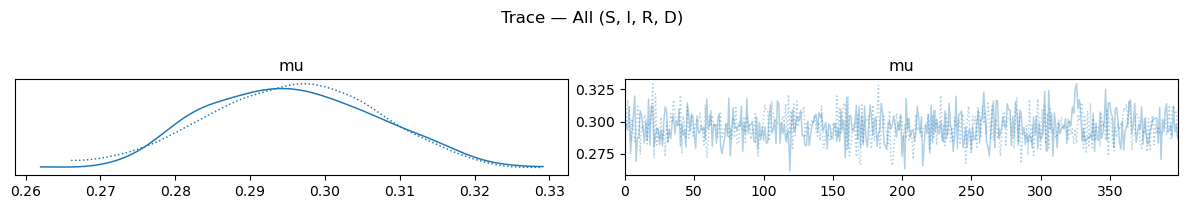

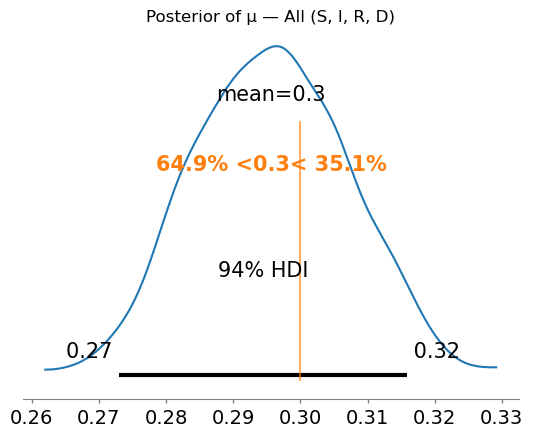

     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu  0.296  0.012   0.273    0.316        0.0      0.0     911.0     669.0   

    r_hat  
mu    1.0  

SIRD with I, R, D


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]


Sampling 2 chains for 1_000 tune and 400 draw iterations (2_000 + 800 draws total) took 365 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


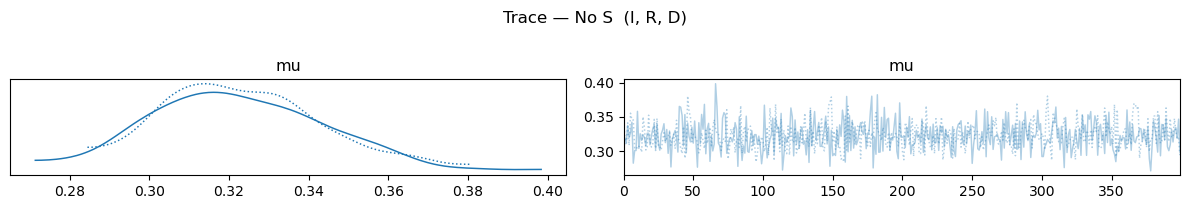

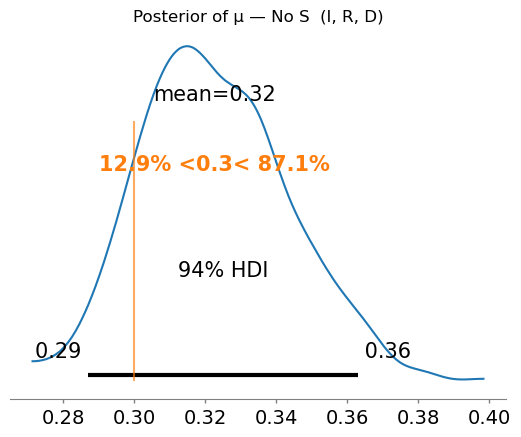

     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu  0.323  0.021   0.287    0.363      0.001    0.001     948.0     590.0   

    r_hat  
mu    1.0  

SIRD with S, I, D


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]


Sampling 2 chains for 1_000 tune and 400 draw iterations (2_000 + 800 draws total) took 364 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


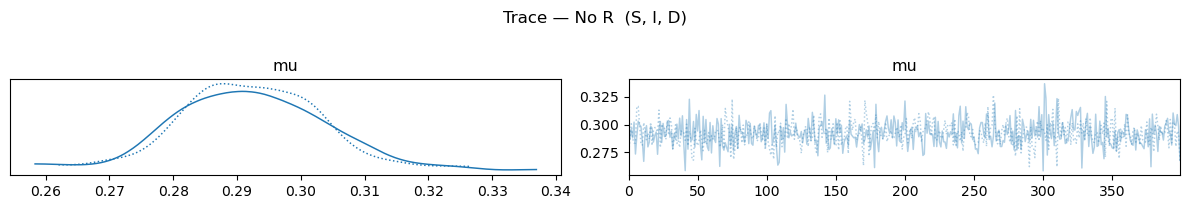

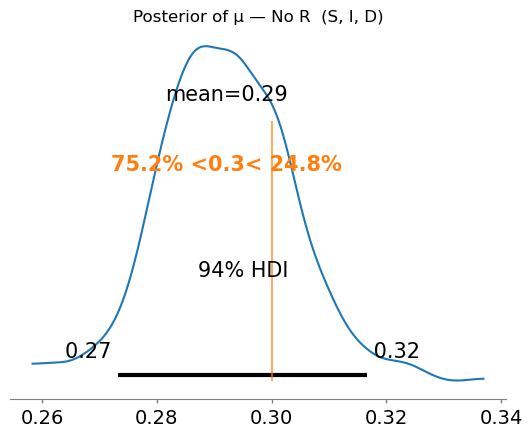

     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu  0.292  0.011   0.273    0.317        0.0      0.0     912.0     761.0   

    r_hat  
mu    1.0  

SIRD with I, D


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]


Sampling 2 chains for 1_000 tune and 400 draw iterations (2_000 + 800 draws total) took 318 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


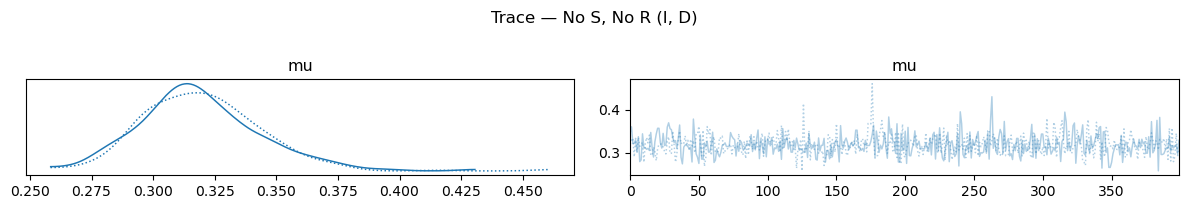

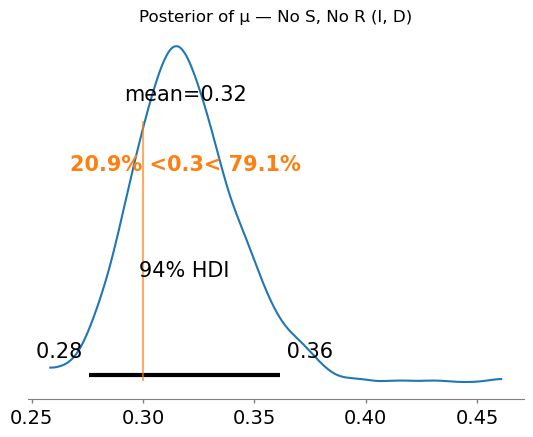

     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu  0.319  0.024   0.276    0.362      0.001    0.001     803.0     601.0   

    r_hat  
mu    1.0  


In [8]:
scenarios = {
    "All (S, I, R, D)" : [0, 1, 2, 3],
    "No S  (I, R, D)"  : [1, 2, 3],
    "No R  (S, I, D)"  : [0, 1, 3],
    "No S, No R (I, D)": [1, 3],
}

traces = {}
for name, cols in scenarios.items():
    traces[name] = run_sird_mcmc(yobs_full, observe_cols=cols)
    plot_results(traces[name], title=name)

## 6. Results & Discussion

### 6.1 Side-by-Side Posterior Comparison

Plotting all four posteriors together makes it easy to see how the width of the credible interval changes as observations are removed. A wider posterior means more uncertainty in $\mu$.

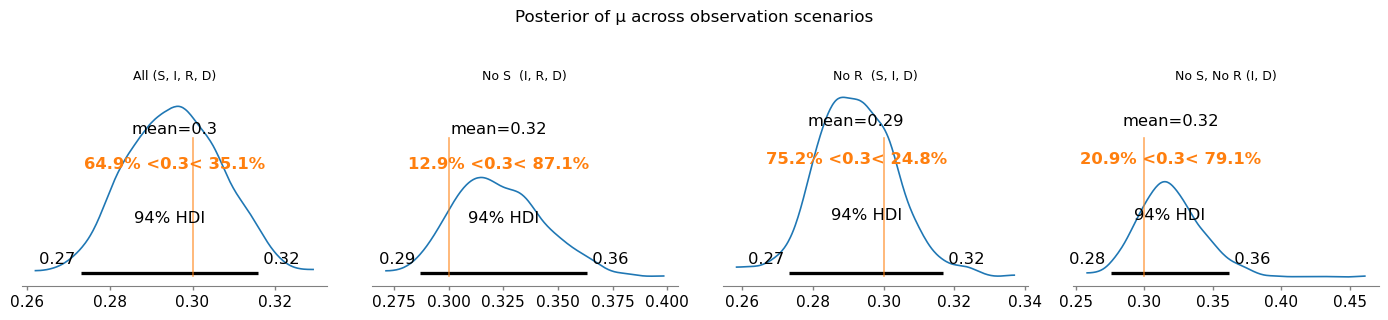

In [9]:
fig, axes = plt.subplots(1, len(scenarios), figsize=(14, 3), sharey=True)
for ax, (name, trace) in zip(axes, traces.items()):
    az.plot_posterior(trace, var_names=["mu"], hdi_prob=0.94,
                      ref_val=mu_true, ax=ax, textsize=11)
    ax.set_title(name, fontsize=9)
fig.suptitle("Posterior of μ across observation scenarios", y=1.05)
plt.tight_layout()
plt.show()

### 6.2 Numerical Summary

The table below compares the posterior mean and 94% HDI for each scenario against the true value $\mu = 0.3$. A ✓ indicates the true value falls inside the credible interval — i.e. the inference is correctly calibrated.

In [11]:
print("=" * 72)
print("        MCMC INFERENCE RESULTS ACROSS SCENARIOS")
print("=" * 72)
print(f"{'Scenario':<22} {'Mean μ':>8} {'HDI low':>9} {'HDI high':>9} {'Width':>7} {'True in HDI?':>12}")
print("-" * 72)

for name, trace in traces.items():
    mu_samples = trace.posterior["mu"].values.flatten()
    mu_mean    = mu_samples.mean()
    hdi        = az.hdi(trace, var_names=["mu"], hdi_prob=0.94)["mu"].values
    width      = hdi[1] - hdi[0]
    in_hdi     = "✓" if hdi[0] <= mu_true <= hdi[1] else "✗"
    print(f"{name:<22} {mu_mean:>8.4f} {hdi[0]:>9.4f} {hdi[1]:>9.4f} {width:>7.4f} {in_hdi:>12}")

print("=" * 72)
print(f"True μ = {mu_true}   (True R₀ = β/(γ+μ) = {beta/(gamma+mu_true):.4f})")

        MCMC INFERENCE RESULTS ACROSS SCENARIOS
Scenario                 Mean μ   HDI low  HDI high   Width True in HDI?
------------------------------------------------------------------------
All (S, I, R, D)         0.2956    0.2730    0.3159  0.0429            ✓
No S  (I, R, D)          0.3227    0.2871    0.3631  0.0761            ✓
No R  (S, I, D)          0.2922    0.2733    0.3167  0.0434            ✓
No S, No R (I, D)        0.3193    0.2755    0.3617  0.0862            ✓
True μ = 0.3   (True R₀ = β/(γ+μ) = 1.9231)


### 6.3 Interpretation

**What the trace plots tell us:** Each trace plot has two panels. The right panel shows sampled values of μ over MCMC iterations — a stationary, well-mixed signal (a "hairy caterpillar") indicates convergence. The left panel is the resulting marginal posterior density. The two chains (solid and dotted) should overlap closely.

**What the HPD plots tell us:** The orange vertical line marks the true μ = 0.3. The black bar is the 94% Highest Posterior Density (HDI) interval — the shortest interval containing 94% of posterior probability. The percentages show how much of the posterior falls below and above the true value; values near 50%/50% mean the posterior is well-centred on the truth.

**Key findings:**

1. **All scenarios successfully recover μ** — the true value μ = 0.3 falls inside the 94% HDI in every case (✓), confirming that the inference is correctly calibrated despite noisy observations.

2. **Removing S(t) widens the posterior** — comparing "All" (HDI width 0.043) vs "No S" (width 0.076), removing S roughly doubles the uncertainty. Although S is theoretically redundant — it can always be reconstructed from S = 1 − I − R − D — observing it directly still provides an additional noisy measurement that constrains the ODE solution. With noisy data, more observations always help, even redundant ones.

3. **Removing R(t) has almost no effect** — comparing "All" (0.043) vs "No R" (0.044), the HDI width is nearly identical. This makes sense: R does not appear in the death equation dD/dt = μ·I at all, so it carries no direct information about μ. Once I(t) and D(t) are observed, R(t) adds nothing.

4. **D(t) alone carries the core signal for μ** — even in the hardest case (I, D only), the true μ is recovered with a reasonable HDI of [0.276, 0.362]. Since dD/dt = μ·I, the death curve directly encodes μ given I(t), making inference possible with minimal observations.

5. **Slight asymmetry in the posteriors** — scenarios without S show the orange reference line noticeably off-centre (e.g. 12.9%/87.1% for No S), meaning the posterior is skewed slightly above the truth. With fewer constraints, the sampler has more freedom to explore higher μ values, producing a heavier right tail.

---

### 6.4 Conclusion

The SIRD model was successfully extended from SIR by introducing a death compartment D(t) with rate μ. Using NUTS-based MCMC in PyMC, we inferred μ from noisy synthetic observations under four different partial-observation scenarios.

The inference is robust: the true μ = 0.3 is recovered in all cases, with R₀ = β/(γ+μ) = 1.92. The key insight is that **D(t) directly encodes μ** through dD/dt = μ·I, so I(t) and D(t) are sufficient for identification. Removing R(t) costs nothing, while removing S(t) — despite being theoretically reconstructable — increases uncertainty because it removes a real observational constraint on the ODE solution.